# Kenapa Credit Risk Penting?

Analisis risiko kredit merupakan aspek krusial dalam industri perbankan dan pembiayaan. Ketika institusi keuangan memberikan pinjaman, tidak ada jaminan absolut bahwa dana tersebut akan dikembalikan, bahkan nasabah dengan profil yang tampak baik sekalipun dapat memiliki faktor risiko tersembunyi yang meningkatkan kemungkinan gagal bayar ***default***. Konsekuensi dari kesalahan prediksi tidak simetris. Menyetujui pinjaman kepada nasabah pada akhirnya ***default*** berarti kehilangan seluruh pokok pinjaman, sedangkan menolak nasabah yang sebenarnya mampu membayar hanya berarti kehilangan potensi keuntungan. Hoffmann (1994) dalam German Credit Dataset mengkuantifikasi asimetri ini melalui cost matrix: biaya salah mengklasifikasikan nasabah buruk sebagai baik 5 kali lebih besar dibandingkan sebaliknya.

Berdasarkan kerangka cost tersebut, proyek ini bertujuan untuk meminimalkan total kerugian klasifikasi dari German Credit Dataset dengan membandingkan dua pendekatan model (**Logistic Regression** dan **Random Forest**) menggunakan cost metric yang mengacu langsung pada rekomendasi dataset.

# Exploratory Data Analysis

## Load & Splitting Dataset

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

col_name = [
      'status', 'duration', 'credit_hist', 'purpose', 'amount', 'savings', 'employment', 'install_rate', 'personal_status', 'debtors', 'residence', 'property', 'age', 'install_plans', 'housing', 'existing_credits', 'job', 'num_dependents', 'telephone', 'foreign', 'label'
]

df = pd.read_csv('data/german.data', sep=r'\s+', names=col_name, header=None)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   status            1000 non-null   str  
 1   duration          1000 non-null   int64
 2   credit_hist       1000 non-null   str  
 3   purpose           1000 non-null   str  
 4   amount            1000 non-null   int64
 5   savings           1000 non-null   str  
 6   employment        1000 non-null   str  
 7   install_rate      1000 non-null   int64
 8   personal_status   1000 non-null   str  
 9   debtors           1000 non-null   str  
 10  residence         1000 non-null   int64
 11  property          1000 non-null   str  
 12  age               1000 non-null   int64
 13  install_plans     1000 non-null   str  
 14  housing           1000 non-null   str  
 15  existing_credits  1000 non-null   int64
 16  job               1000 non-null   str  
 17  num_dependents    1000 non-null   int64
 18  

Output dari `df.info()` menunjukkan tidak ada nilai yang hilang, sehingga tidak perlu menghandle missing value

### Penjelasan kelas untuk setiap kolom kategorikal

##### 1. Status (Likuiditas Jangka Pendek)

Menggambarkan saldo di rekening giro nasabah pada saat pengajuan.

* **A11**: < 0 DM (Saldo negatif/minus)
* **A12**: 0 <= ... < 200 DM (Saldo rendah)
* **A13**: >= 200 DM / Gaji masuk tetap (Saldo stabil)
* **A14**: Tidak memiliki rekening giro

##### 2. Savings (Tabungan)

Menggambarkan cadangan dana likuid jangka panjang (dana darurat).

* **A61**: < 100 DM
* **A62**: 100 <= ... < 500 DM
* **A63**: 500 <= ... < 1000 DM
* **A64**: >= 1000 DM
* **A65**: Tidak diketahui / tidak memiliki tabungan

##### 3. Credit_hist (Kedisiplinan Membayar)

Rekam jejak perilaku pembiayaan sebelumnya.

* **A30**: Belum pernah ambil kredit / Semua terbayar tepat waktu
* **A31**: Semua kredit di bank ini terbayar tepat waktu
* **A32**: Kredit yang ada terbayar tepat waktu sampai saat ini
* **A33**: Pernah terlambat membayar di masa lalu
* **A34**: Akun kritis / Ada kredit di tempat lain

##### 4. Purpose (Tujuan Pinjaman)

Niat penggunaan dana pinjaman.

* **A40**: Mobil (Baru) | **A41**: Mobil (Bekas)
* **A42**: Furnitur/Peralatan | **A43**: Radio/Televisi
* **A44**: Alat Rumah Tangga | **A45**: Perbaikan (Repairs)
* **A46**: Pendidikan | **A48**: Pelatihan Ulang (Retraining)
* **A49**: Bisnis | **A410**: Lain-lain

##### 5. Employment (Pengalaman Kerja)
Stabilitas penghasilan berdasarkan masa kerja.

* **A71**: Menganggur (Unemployed)
* **A72**: < 1 tahun
* **A73**: 1 <= ... < 4 tahun
* **A74**: 4 <= ... < 7 tahun
* **A75**: >= 7 tahun

##### 6. Property (Aset Properti)

Aset tetap yang dimiliki sebagai jaminan terselubung.

* **A121**: Real Estate (Rumah/Tanah)
* **A122**: Tabungan bangunan / Asuransi jiwa
* **A123**: Mobil atau aset lainnya
* **A124**: Tidak diketahui / tidak punya properti

##### 7. Housing (Biaya Hidup Tetap)

Kondisi tempat tinggal yang memengaruhi beban pengeluaran.

* **A151**: Sewa (Rent)
* **A152**: Milik Sendiri (Own)
* **A153**: Gratis / Tanpa biaya (For free)

##### 8. Install_plans (Cicilan di Tempat Lain)

Komitmen keuangan nasabah pada institusi lain.

* **A141**: Ada cicilan di Bank lain
* **A142**: Ada cicilan di Toko (Stores)
* **A143**: Tidak ada cicilan lain

##### 9. Label

* **0**: Nasabah baik
* **1**: Nasabah buruk


## Analisis Univariate

In [31]:
from sklearn.model_selection import train_test_split
# Mapping label target, baik = 0, buruk = 1
df['label'] = df['label'].map({1: 0, 2: 1})
X = df.drop(columns=['label'])
y = df['label']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

train_df = X_train.copy()
train_df['label'] = y_train.values

### Distribusi Target

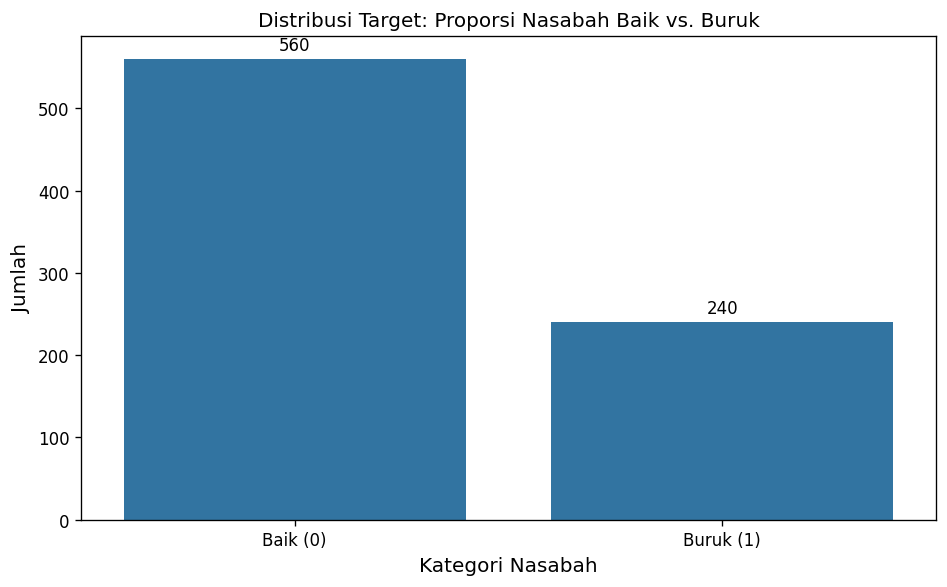

In [3]:


plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.autolayout'] = True

ax = sns.countplot(data=train_df, x='label')

for container in ax.containers:
    ax.bar_label(container, padding=3) # type: ignore
plt.title('Distribusi Target: Proporsi Nasabah Baik vs. Buruk')
plt.xlabel('Kategori Nasabah', fontsize=12)
plt.ylabel('Jumlah', fontsize=12)

plt.xticks(ticks=[0, 1], labels=['Baik (0)', 'Buruk (1)'])
plt.show()

Hasil analisis univariat menunjukkan adanya masalah ketidakseimbangan data dengan proporsi: 

* **Kelas 0 (Nasabah Baik):** 560 data
* **Kelas 1 (Nasabah Buruk):** 240 data

Ketidakseimbangan proporsi ini menyebabkan model mengalami **bias**. Model akan cenderung lebih dominan memprediksi nasabah ke dalam kelas mayoritas (Kelas 0) dan kesulitan untuk mengidentifikasi karakteristik nasabah pada kelas minoritas (Kelas 1/gagal bayar).

Untuk mengatasi masalah ini, proyek ini akan menerapkan pendekatan **Class Weight** saat melatih model karena kita akan mempertahankan seluruh informasi asli tanpa perlu membuang data penting (*undersampling*) atau mensintesis data baru(*oversampling*).

## Multivariate Analysis

### Numerical Features

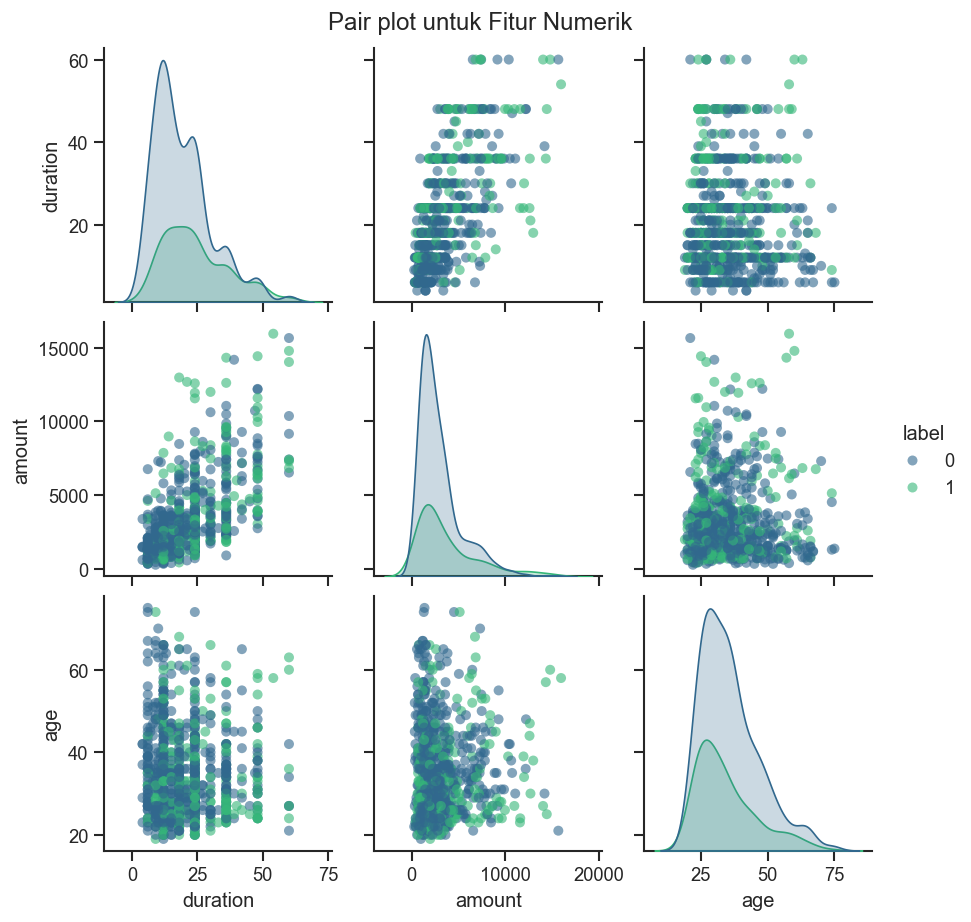

In [4]:
num_cat = ['duration', 'amount', 'age']
sns.set_theme(style='ticks')
pair_plot = sns.pairplot(
    train_df[['duration', 'amount', 'age', 'label']],
    hue='label',
    palette='viridis',
    diag_kind='kde',
    plot_kws={
        'alpha': 0.6,
        'edgecolor': 'none'
    }
)

pair_plot.figure.suptitle('Pair plot untuk Fitur Numerik', y=1.02)
plt.show()

#### Key Insights

1. Terdapat hubungan linear positif yang jelas antara jumlah pinjaman (`amount`) dengan tenor (`duration`)
2. Variabel `age` cenderung membentuk pola acak terhadap `amount` maupun `duration`. Hal ini mengindikasikan bahwa usia nasabah tidak memiliki hubungan linear secara langsung
3. Ketiga variabel numerikal (`duration`, `amount`, dan `age`) menunjukkan distribusi yang miring ke kanan


#### pointbiserialr

In [5]:
from scipy.stats import pointbiserialr

num_analysis = []

for col in num_cat:
    corr, p_val = pointbiserialr(train_df[col], train_df['label'])
    skew = train_df[col].skew()
    num_analysis.append({'feature': col, 'correlation': corr, 'p_value': p_val, 'skew': skew})
num_df = pd.DataFrame(num_analysis)
num_df.sort_values(by='correlation', ascending=False)


,feature,correlation,p_value,skew
0,duration,0.206301,3.875571e-09,1.046744
1,amount,0.138776,8.212145e-05,1.826435
2,age,-0.057750,1.026316e-01,1.043352


Hasil analisis korelasi Point-Biserial menunjukkan `duration` pinjaman memiliki korelasi positif terkuat (r $\approx 0.20$, p < 0,001) diikuti oleh jumlah pinjaman (`amount`) sebesar 0.13, sementara usia memiliki korelasi negatif yang sangat lemah(r $\approx$-0.05). Hal ini mengindikasikan:
1. Semakin besar tenor dan semakin besar nominal kredit yang dicairkan, probabilitas nasabah mengalami gagal bayar semakin besar
2. Usia berkorelasi negatif sangat lemah dan tidak signifikan secara statistik (p ≈ 0.10); arahnya mengindikasikan usia lebih tua cenderung berisiko lebih rendah, namun belum cukup kuat untuk disimpulkan.

### Uji Korelasi antar fitur

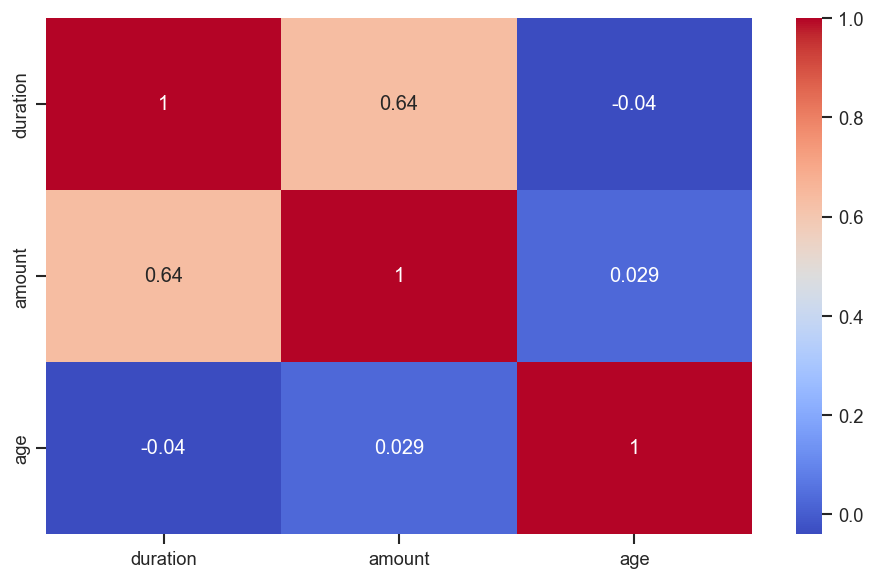

In [6]:
sns.heatmap(train_df[num_cat].corr(), cmap='coolwarm', annot=True)
plt.show()

Ditemukan korelasi positif (0.64) antara durasi pinjaman dengan jumlah yang dipinjamkan. Hubungan ini mencerminkan jumlah uang yang dipinjamkan membesar mengharuskan perpanjangan tenor pelunasan. Nilai 0.64 dinilai belum melampaui ambang batas kolinearitas kritis (umumnya 0.7-0.9) yang dapat menyebabkan bias dalam training model regresi logistik. Oleh karena itu, kedua fitur ini dipertahankan.

### Categorical Feature

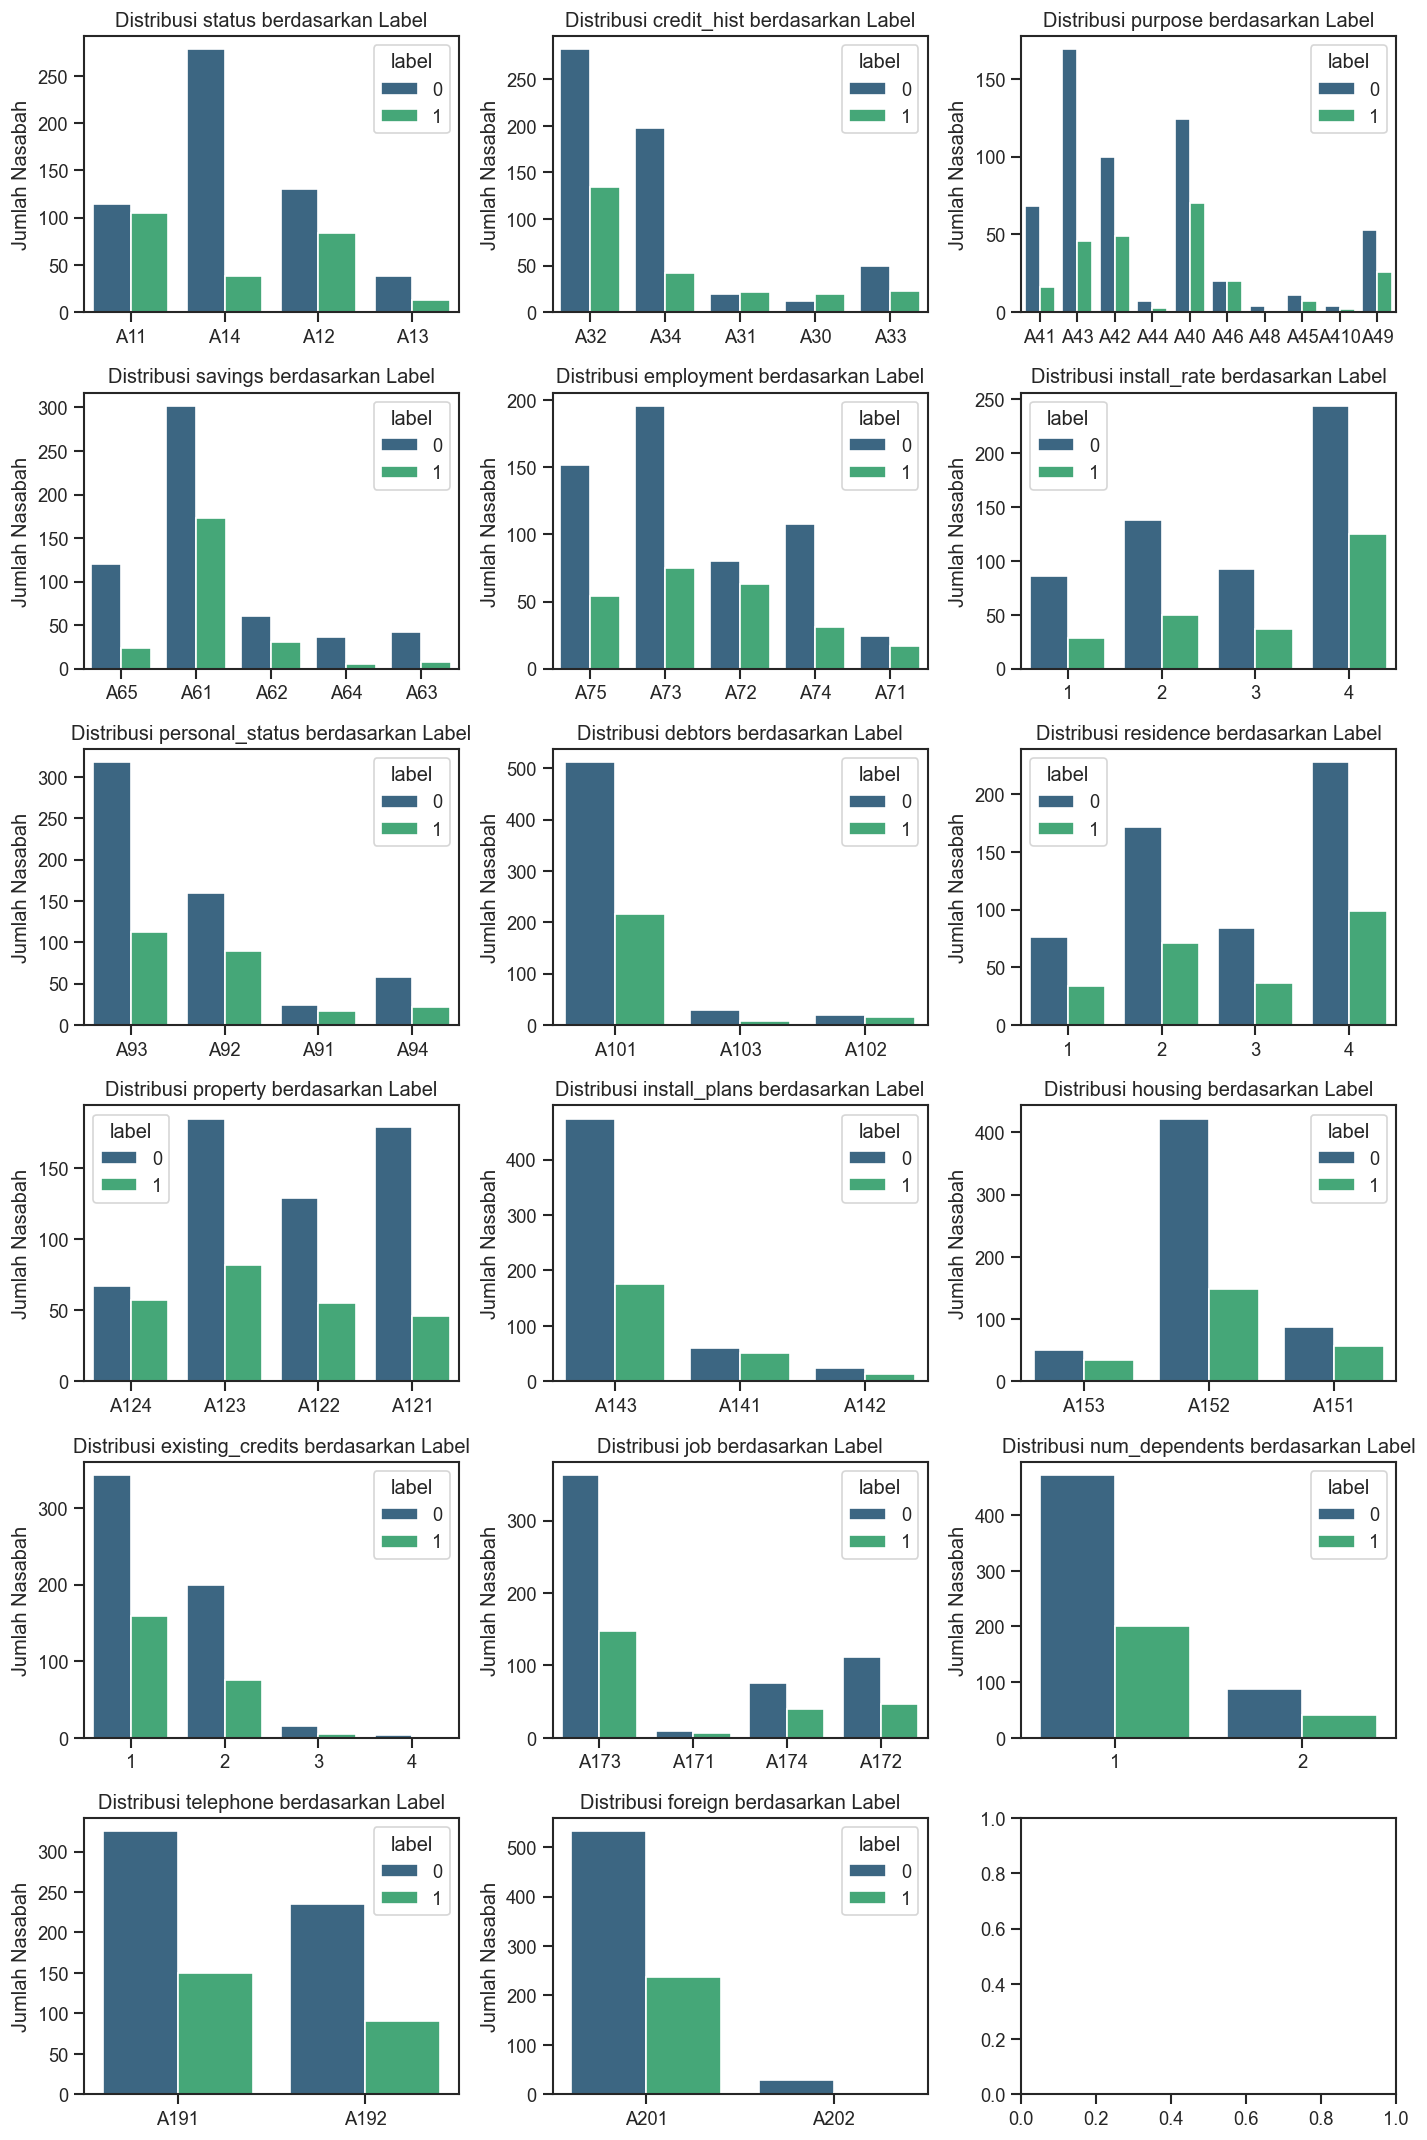

In [7]:
cat_filter = ['duration', 'amount', 'age', 'label']
cat_feat = train_df.drop(columns=cat_filter).columns.tolist()

fig, axes = plt.subplots(nrows=6, ncols=3, figsize=(12, 18))
axes = axes.flatten()

for i, col in enumerate(cat_feat):
    sns.countplot(data=train_df, x=col, hue='label', ax=axes[i], palette='viridis')

    axes[i].set_title(f'Distribusi {col} berdasarkan Label')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Jumlah Nasabah')
plt.tight_layout()
plt.show()

### Uji Chi-Square

In [8]:
from scipy.stats import chi2_contingency

chi2_results = []

for col in cat_feat:
    contingency_table = pd.crosstab(train_df[col], train_df['label'])
    chi2, p, dof, _ = chi2_contingency(contingency_table)
    chi2_results.append({'feature': col, 'chi2': chi2, 'p_value': p})

chi2_df = pd.DataFrame(chi2_results).sort_values('p_value')
print(chi2_df.to_string(index=False))

         feature      chi2      p_value
          status 91.417972 1.086352e-19
     credit_hist 44.336777 5.461188e-09
         savings 32.848463 1.282923e-06
        property 24.903787 1.617248e-05
      employment 22.045198 1.963109e-04
   install_plans 16.365890 2.793780e-04
         housing 15.403601 4.520126e-04
         purpose 25.272173 2.684404e-03
 personal_status  9.914850 1.930398e-02
         foreign  5.375745 2.041862e-02
         debtors  4.482577 1.063214e-01
    install_rate  5.388771 1.454448e-01
       telephone  1.209177 2.714952e-01
             job  2.001996 5.719925e-01
existing_credits  1.855975 6.028304e-01
  num_dependents  0.053589 8.169316e-01
       residence  0.125828 9.885672e-01


#### Fitur-fitur kurang diskriminatif

- `telephone` (p=0.27): distribusi cukup merata antar kelas
- `num_dependents` (p=0.82): hampir seluruh data bernilai 1, tidak ada variasi
- `residence` (p=0.99): distribusi relatif merata antar kelas
- `existing_credits` (p=0.6): mayoritas bernilai 1, variasi sangat sedikit
- `install_rate` (p=0.14): meskipun memiliki 4 kategori, secara statistik tidak berhubungan signifikan dengan label
- `job` (p=0.57): distribusi antar kelas tidak berbeda secara signifikan

# Feature Engineering

In [9]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Urutan kategori untuk fitur ordinal
status = ['A14', 'A11', 'A12', 'A13']
history = ['A34', 'A33', 'A30', 'A32', 'A31']
savings = ['A65', 'A61', 'A62', 'A63', 'A64']
employ = ['A71', 'A72', 'A73', 'A74', 'A75']
job = ['A171', 'A172', 'A173', 'A174']

ordinal_features = ['status', 'credit_hist', 'savings', 'employment', 'job']
ordinal_cat = [status, history, savings, employ, job]
nominal_features = [col for col in cat_feat if col not in ordinal_features]

numeric_transformer = Pipeline([
    ('scaler', StandardScaler())
])

ordinal_transformer = OrdinalEncoder(
    categories=ordinal_cat,
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

nominal_transformer = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cat),
        ('ord', ordinal_transformer, ordinal_features),
        ('nom', nominal_transformer, nominal_features),
    ],
    remainder='drop'
)


In [10]:
# WoE encoding
from category_encoders import WOEEncoder

cat_cols = [c for c in cat_feat]
num_cols = num_cat

preprocessor_woe = ColumnTransformer(
    transformers=[
        ('woe', WOEEncoder(regularization=0.5), cat_cols),
        ('scaler', StandardScaler(), num_cols)
    ]
)


## Cost-Matrix


Evaluasi model dalam proyek ini tidak menggunakan accuracy sebagai metrik utama.
Sebagai gantinya, digunakan **cost matrix** yang diambil langsung dari dokumentasi
resmi dataset German Credit (Prof. Hans Hofmann, Universität Hamburg):

|                  | Predicted: Good (0) | Predicted: Bad (1) |
|------------------|---------------------|--------------------|
| **Actual: Good (0)** | 0               | 1                  |
| **Actual: Bad (1)**  | 5               | 0                  |

Interpretasi:
- **False Positive (FP)** — nasabah *baik* diprediksi *buruk* → cost **1**
- **False Negative (FN)** — nasabah *buruk* diprediksi *baik* → cost **5**

Rasio 5:1 ini mencerminkan **meloloskan nasabah buruk
jauh lebih merugikan** dibandingkan menolak nasabah yang sebenarnya baik.
Nasabah yang gagal bayar berpotensi menyebabkan kerugian langsung (pokok +
bunga yang hilang), sementara menolak nasabah baik hanya berarti kehilangan
peluang bisnis.

Total cost dihitung sebagai:

$$\text{Total Cost} = (FP \times 1) + (FN \times 5)$$

Model terbaik adalah model dengan **total cost terendah**.

# Modelling

## Logistic Regression

### Baseline dengan Standar Feature Engineering (Standard Scaler, Ordinal, dan OHE)

In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import make_scorer

baseline_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression( l1_ratio=1, solver='liblinear', C=1, random_state=42, class_weight='balanced'))
])

def credit_cost_loss(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    # Cost matrix German Credit (Hofmann): FN (buruk lolos)=5, FP (baik ditolak)=1
    return (fn * 5) + (fp * 1)


cost_scorer = make_scorer(credit_cost_loss, greater_is_better=False)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


param_grid = [
    {
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['liblinear'],
        'classifier__class_weight': ['balanced']
    },
    # l1_ratio
    {
        'classifier__l1_ratio': [1],
        'classifier__C': [0.01, 0.1, 1, 10],
        'classifier__solver': ['saga'],
        'classifier__class_weight': ['balanced']
    }
]


baseline_pipe.fit(X_train, y_train)
y_pred = baseline_pipe.predict(X_test)

print('Baseline')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Baseline
[[93 47]
 [17 43]]
              precision    recall  f1-score   support

           0       0.85      0.66      0.74       140
           1       0.48      0.72      0.57        60

    accuracy                           0.68       200
   macro avg       0.66      0.69      0.66       200
weighted avg       0.74      0.68      0.69       200



In [12]:
from sklearn.model_selection import cross_val_score

# Menghitung skor secara otomatis
scores = cross_val_score(baseline_pipe, X_train, y_train, cv=skf, scoring=cost_scorer)

print("Skor Cost matrix per fold:", -scores)
print(f"Rata-rata Cost matrix: {-scores.mean():.4f}")

Skor Cost matrix per fold: [126 100 109 150 104]
Rata-rata Cost matrix: 117.8000


#### Optimisasi dengan GridSearchCV

In [13]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline


pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(
        class_weight='balanced', 
        l1_ratio=1, 
        solver='liblinear', 
        C=1, 
        max_iter=5000  # <--- Tambahkan ini
    ))
])

grid_search = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=skf, scoring=cost_scorer )
grid_search.fit(X_train, y_train)

print("Parameter Terbaik:", grid_search.best_params_)

Parameter Terbaik: {'classifier__C': 1, 'classifier__class_weight': 'balanced', 'classifier__l1_ratio': 1, 'classifier__solver': 'saga'}


#### Training ulang model

In [14]:

baseline_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(solver='saga', C=1, l1_ratio=1, max_iter=5000, class_weight='balanced'))
])

baseline_pipe.fit(X_train, y_train)
y_pred = baseline_pipe.predict(X_test)

print('Optimisasi Baseline')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Optimisasi Baseline
[[93 47]
 [18 42]]
              precision    recall  f1-score   support

           0       0.84      0.66      0.74       140
           1       0.47      0.70      0.56        60

    accuracy                           0.68       200
   macro avg       0.65      0.68      0.65       200
weighted avg       0.73      0.68      0.69       200



In [15]:
from sklearn.model_selection import cross_val_score

# Menghitung skor secara otomatis
scores = cross_val_score(baseline_pipe, X_train, y_train, cv=skf, scoring=cost_scorer)

print("Skor Cost matrix per fold:", -scores)
print(f"Rata-rata Cost matrix: {-scores.mean():.4f}")


Skor Cost matrix per fold: [126 101 109 147 104]
Rata-rata Cost matrix: 117.4000


### Weight of Evidence (WoE)

WoE merepresentasikan seluruh kelas dalam satu fitur sebagai satu nilai numerik yang mengandung informasi terhadap risiko dengan persamaan:

$$
WoE = \ln (\frac{\% Bad}{\% Good})
$$

Logistic regression cukup mempelajari satu koefisien per fitur sehingga lebih stabil pada dataset berukuran kecil.

#### Optimisasi dengan GridSearchCV

In [16]:
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold


pipe = Pipeline([
    ('preprocessor', preprocessor_woe),
    ('classifier', LogisticRegression(
        l1_ratio=1, 
        solver='liblinear', 
        C=1, 
        max_iter=5000,
        class_weight='balanced'
    ))
])

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)



grid_search = GridSearchCV(estimator=pipe, param_grid=param_grid, cv=skf, scoring=cost_scorer )
grid_search.fit(X_train, y_train)

print("Parameter Terbaik:", grid_search.best_params_)

Parameter Terbaik: {'classifier__C': 0.1, 'classifier__class_weight': 'balanced', 'classifier__solver': 'liblinear'}


### Training ulang

In [17]:
pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_woe),
    ('classifier', LogisticRegression(solver='liblinear', C=0.1, class_weight='balanced'))
])

pipeline.fit(X_train, y_train)

y_pred_proba_lr = pipeline.predict_proba(X_test)[:, 1]
y_pred_woe = (y_pred_proba_lr >= 0.5).astype(int)

print('Optimisasi model dengan WoE')
print(confusion_matrix(y_test, y_pred_woe))
print(classification_report(y_test, y_pred_woe))

Optimisasi model dengan WoE
[[104  36]
 [ 12  48]]
              precision    recall  f1-score   support

           0       0.90      0.74      0.81       140
           1       0.57      0.80      0.67        60

    accuracy                           0.76       200
   macro avg       0.73      0.77      0.74       200
weighted avg       0.80      0.76      0.77       200



In [18]:
from sklearn.model_selection import cross_val_score

# Menghitung skor secara otomatis
scores = cross_val_score(pipeline, X_train, y_train, cv=skf, scoring=cost_scorer)

print("Skor Cost matrix per fold:", -scores)
print(f"Rata-rata Cost matrix: {-scores.mean():.4f}")


Skor Cost matrix per fold: [ 87  92  81 145  95]
Rata-rata Cost matrix: 100.0000


### Feature Importance

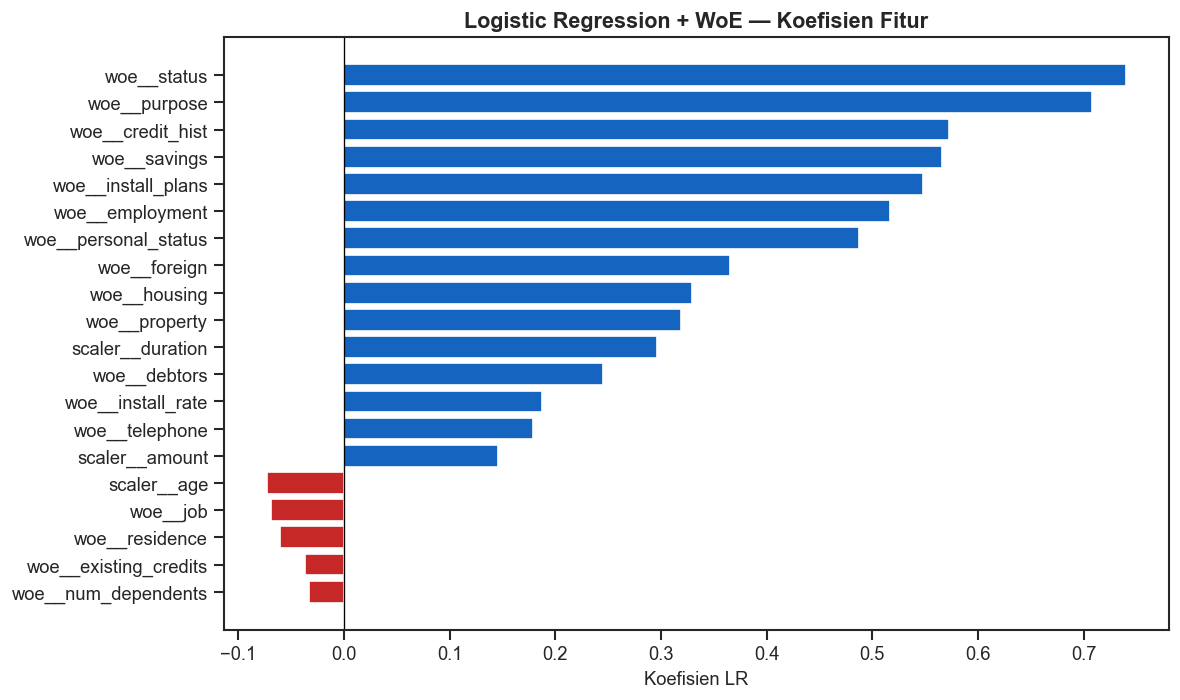

In [19]:


coef_values = pipeline.named_steps['classifier'].coef_[0]  
feature_names_woe = X_train.columns.tolist()          

coef_df = pd.DataFrame({
    'Feature': pipeline.named_steps['preprocessor'].get_feature_names_out(),
    'Coefficient': coef_values
})
coef_df['Abs_Coef'] = coef_df['Coefficient'].abs()
coef_df = coef_df.sort_values('Abs_Coef', ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#1565C0' if c > 0 else '#C62828' for c in coef_df['Coefficient'][::-1]]
ax.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Koefisien LR', fontsize=11)
ax.set_title('Logistic Regression + WoE — Koefisien Fitur', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

In [20]:

# Get WOE mappings from the encoder
woe_encoder = pipeline.named_steps['preprocessor'].named_transformers_['woe']
pd.DataFrame(woe_encoder.mapping)

,status,credit_hist,purpose,savings,employment,personal_status,debtors,property,install_plans,housing,job,telephone,foreign
-2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
-1,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.763060,0.102810,-0.578549,-0.748053,-0.184040,-0.195745,-0.012178,0.684581,-0.149699,0.472875,-0.050270,0.073525,0.037509
2,-1.133836,-0.696361,-0.448477,0.289020,-0.111606,0.260869,-0.399400,0.034667,0.667469,-0.200681,0.365351,-0.111437,-1.252217
3,0.410302,0.988025,0.136739,0.160007,0.607707,0.508452,0.615350,-0.002374,0.280394,0.425070,0.222093,NaN,NaN
4,-0.203045,1.289610,0.082784,-1.047640,-0.391839,-0.110587,NaN,-0.505799,NaN,NaN,-0.038577,NaN,NaN
5,NaN,0.099952,0.276231,-0.764514,0.508452,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,NaN,NaN,0.844924,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,NaN,NaN,-0.253688,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,NaN,NaN,0.417480,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- status dan purpose memiliki koefisien terbesar, diikuti credit_hist dan savings —
  konsisten dengan chi-square yang menempatkan status & credit_hist paling signifikan.
- job, residence, existing_credits, dan num_dependents berkoefisien mendekati nol/negatif
  kecil, diserahkan ke regularisasi L1 — sejalan dengan chi-square bahwa fitur-fitur ini
  tidak signifikan.
- age berkoefisien negatif: usia lebih tua diasosiasikan risiko gagal bayar lebih rendah.

## Random Forest

### Baseline

In [21]:
from sklearn.ensemble import RandomForestClassifier
baseline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(n_estimators=300, random_state=42, class_weight='balanced'))
])

baseline_rf.fit(X_train, y_train)

y_pred = baseline_rf.predict(X_test)

print('Baseline RF')
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Baseline RF
[[109  31]
 [ 23  37]]
              precision    recall  f1-score   support

           0       0.83      0.78      0.80       140
           1       0.54      0.62      0.58        60

    accuracy                           0.73       200
   macro avg       0.68      0.70      0.69       200
weighted avg       0.74      0.73      0.73       200



In [22]:

# Menghitung skor secara otomatis
scores = cross_val_score(baseline_rf, X_train, y_train, cv=skf, scoring=cost_scorer)

print("Skor Cost matrix per fold:", -scores)
print(f"Rata-rata Cost matrix: {-scores.mean():.4f}")

Skor Cost matrix per fold: [132 125 121 153 104]
Rata-rata Cost matrix: 127.0000


#### Optimisasi dengan GridSearchCV

In [23]:
param_grid = {
    'classifier__max_depth': [5, 7, 10],
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_features': [5, 7, 10],
    'classifier__min_samples_split': [2, 5, 10],
    'classifier__min_samples_leaf': [1, 2, 4],
    'classifier__random_state': [42],
    'classifier__class_weight': ['balanced']
}

grid_search = GridSearchCV(baseline_rf, param_grid, cv=skf, scoring=cost_scorer )
grid_search.fit(X_train, y_train)

print("Parameter Terbaik:", grid_search.best_params_)

Parameter Terbaik: {'classifier__class_weight': 'balanced', 'classifier__max_depth': 5, 'classifier__max_features': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 300, 'classifier__random_state': 42}


In [24]:
baseline_rf = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(class_weight='balanced', n_estimators=300,random_state=42, max_depth=5, max_features=10, min_samples_leaf=4, min_samples_split=2))
])

baseline_rf.fit(X_train, y_train)

y_pred_proba_rf = baseline_rf.predict_proba(X_test)[:, 1]
y_pred_woe = (y_pred_proba_rf >= 0.5).astype(int)

print('Optimisasi model RF')
print(confusion_matrix(y_test, y_pred_woe))
print(classification_report(y_test, y_pred_woe))

Optimisasi model RF
[[90 50]
 [16 44]]
              precision    recall  f1-score   support

           0       0.85      0.64      0.73       140
           1       0.47      0.73      0.57        60

    accuracy                           0.67       200
   macro avg       0.66      0.69      0.65       200
weighted avg       0.73      0.67      0.68       200



In [25]:
from sklearn.model_selection import cross_val_score

# Menghitung skor secara otomatis
scores = cross_val_score(baseline_rf, X_train, y_train, cv=skf, scoring=cost_scorer)

print("Skor Cost matrix per fold:", -scores)
print(f"Rata-rata Cost matrix: {-scores.mean():.4f}")

Skor Cost matrix per fold: [ 73  94  81 117  81]
Rata-rata Cost matrix: 89.2000


### Feature Importances

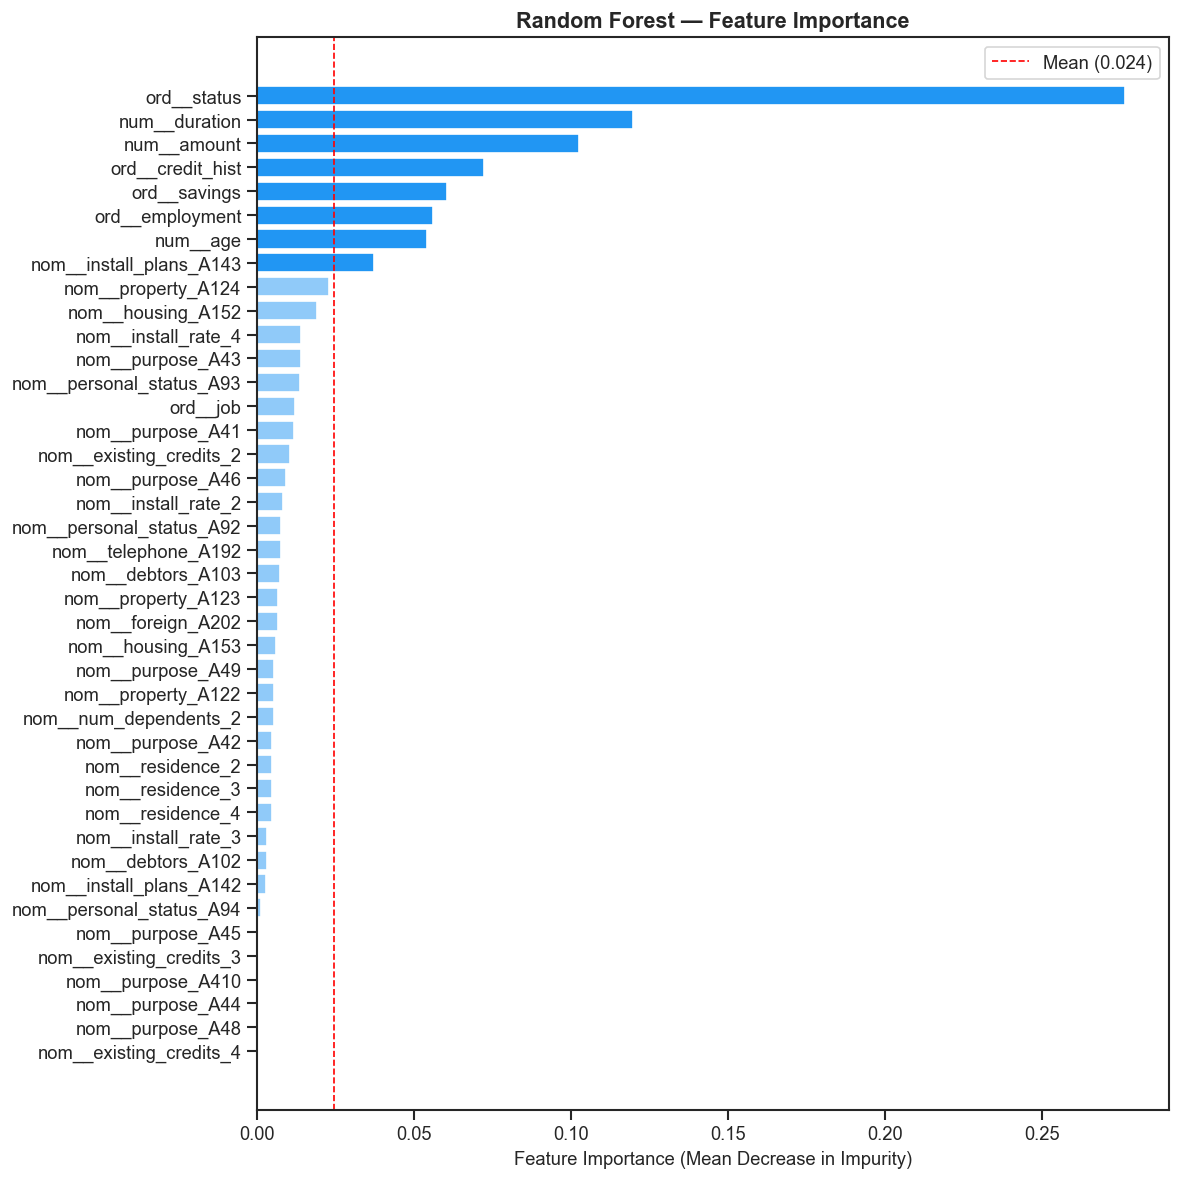

In [26]:
import matplotlib.pyplot as plt
import numpy as np

best_rf = grid_search.best_estimator_

feature_names = X_train.columns.tolist()
importances = best_rf.named_steps['classifier'].feature_importances_

# Sorting
sorted_idx = np.argsort(importances)[::-1]
sorted_importances = importances[sorted_idx]
preproc = best_rf.named_steps['preprocessor']
try:
    transformed_names = preproc.get_feature_names_out()
except Exception:
    transformed_names = preproc.get_feature_names_out(X_train.columns)
sorted_features = [transformed_names[i] for i in sorted_idx]

# Plot
fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#2196F3' if imp > np.mean(importances) else '#90CAF9' for imp in sorted_importances]
bars = ax.barh(sorted_features[::-1], sorted_importances[::-1], color=colors[::-1])

ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)', fontsize=11)
ax.set_title('Random Forest — Feature Importance', fontsize=13, fontweight='bold')
ax.axvline(np.mean(importances), color='red', linestyle='--', linewidth=1, label=f'Mean ({np.mean(importances):.3f})')
ax.legend()

plt.tight_layout()
plt.show()

#### Interpretasi Feature Importance

Fitur dengan importance di atas rata-rata (garis merah putus-putus) adalah
kontributor utama dalam keputusan model RF:

- `status` dan `credit_hist` mendominasi — konsisten dengan hasil chi-square
  yang menunjukkan keduanya paling signifikan secara statistik.
- `amount` dan `duration` (fitur numerik) juga berkontribusi besar,
  mengkonfirmasi temuan point-biserial correlation di tahap EDA.


# Evaluasi dan Perbandingan

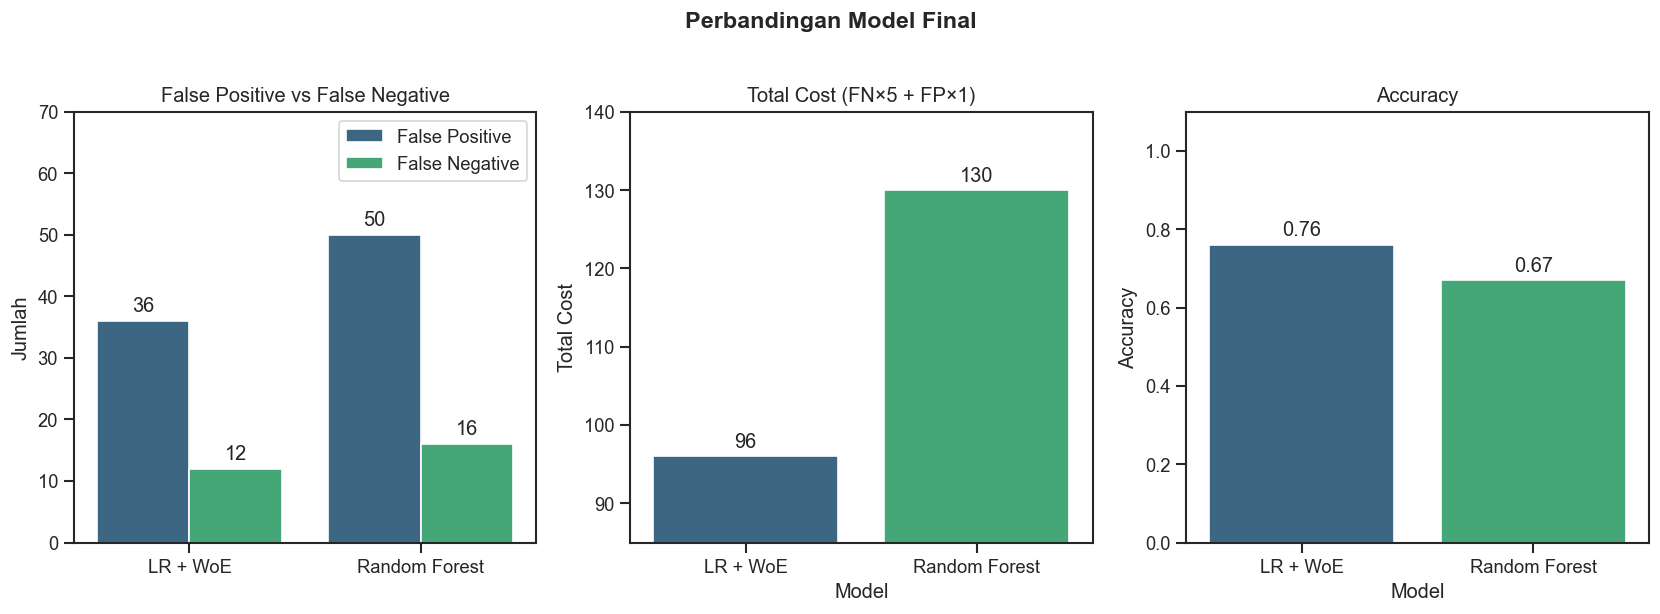

In [27]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# --- Data hasil akhir ---
models = ['LR + WoE', 'Random Forest']
fp_vals = [36, 50]
fn_vals = [12, 16]
cost_vals = [96, 130]
acc_vals = [0.76, 0.67]
x = np.arange(len(models))
width = 0.35
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Perbandingan Model Final', fontsize=14, fontweight='bold', y=1.02)

# Plot 1: FP vs FN
fp_fn_data = pd.DataFrame({
    'Model': models * 2,
    'Jumlah': fp_vals + fn_vals,
    'Tipe': ['False Positive'] * 2 + ['False Negative'] * 2
})
sns.barplot(data=fp_fn_data, x='Model', y='Jumlah', hue='Tipe', ax=axes[0], palette='viridis')
axes[0].set_title('False Positive vs False Negative')
axes[0].set_ylabel('Jumlah')
axes[0].set_xlabel('')
axes[0].set_ylim(0, 70)
axes[0].legend(loc='upper right', bbox_to_anchor=(1, 1))
for container in axes[0].containers:
    axes[0].bar_label(container, padding=3)

# Plot 2: Total Cost
cost_data = pd.DataFrame({'Model': models, 'Total Cost': cost_vals})  # ← tambah ini
sns.barplot(data=cost_data, x='Model', y='Total Cost', hue='Model', legend=False, ax=axes[1], palette='viridis')
axes[1].set_title('Total Cost (FN×5 + FP×1)')
axes[1].set_ylabel('Total Cost')
axes[1].set_ylim(85, 140)  
for container in axes[1].containers:
    axes[1].bar_label(container, padding=3)

# Plot 3: Accuracy
acc_data = pd.DataFrame({'Model': models, 'Accuracy': acc_vals})  # ← tambah ini
sns.barplot(data=acc_data, x='Model', y='Accuracy', hue='Model', legend=False, ax=axes[2], palette='viridis')
axes[2].set_title('Accuracy')
axes[2].set_ylabel('Accuracy')
axes[2].set_ylim(0, 1.1)
for container in axes[2].containers:
    axes[2].bar_label(container, fmt='%.2f', padding=3)

plt.tight_layout()
plt.show()

In [28]:
import pandas as pd

progression_data = {
    'Tahap': [
        'Baseline (Ordinal+OHE)',
        '+ GridSearch (Ordinal+OHE)',
        '+ WoE Encoding',
        'Baseline',
        '+ GridSearch Penuh',
    ],
    'Model': [
        'Logistic Regression', 'Logistic Regression', 'Logistic Regression',
        'Random Forest', 'Random Forest'
    ],
    'FP': [47, 47, 36, 31, 50],
    'FN': [17, 18, 12, 23, 16],
    'Total Cost': [132, 137, 96, 146, 130],
    'Rata-rata Cost Matriks': [117.8, 117.4, 100, 127, 89.2]
}

df_prog = pd.DataFrame(progression_data)
df_prog

,Tahap,Model,FP,FN,Total Cost,Rata-rata Cost Matriks
0,Baseline (Ordinal+OHE),Logistic Regression,47,17,132,117.8
1,+ GridSearch (Ordinal+OHE),Logistic Regression,47,18,137,117.4
2,+ WoE Encoding,Logistic Regression,36,12,96,100.0
3,Baseline,Random Forest,31,23,146,127.0
4,+ GridSearch Penuh,Random Forest,50,16,130,89.2


#### Mengapa LR + WoE Dipilih Meski CV Random Forest Lebih Rendah

Sekilas Random Forest tampak unggul, rata-rata cost cross-validation-nya paling rendah (89.2) dibanding LR + WoE (100.0). Namun pada **test set yang dikunci sejak awal**, urutannya terbalik, LR + WoE mencapai cost 96, sementara Random Forest melonjak ke 130.

| Model | Cost CV (train) | Cost Test (hold-out) | Pola |
|---|---|---|---|
| LR + WoE | 100.0 | 96 | konsisten |
| Random Forest | 89.2 | 130 | divergen (+46%) |

Perbedaan ini merupakan konsekuensi dari **selection bias saat tuning**:

1. **Ukuran grid yang timpang.** GridSearch Random Forest mencari 243 kombinasi
   hyperparameter, sedangkan Logistic Regression hanya 8. Semakin banyak kombinasi yang diuji pada fold yang sama, semakin besar peluang sebuah konfigurasi "beruntung" mencocokkan noise fold, bukan pola yang sebenarnya. Skor CV dari best param karena itu bersifat optimistis secara konstruksi.

2. **Signal-to-noise yang rendah.** Dataset hanya 1000 sampel dengan fitur yang relatif lemah secara prediktif. Ketika sinyal asli tipis, ruang untuk overfit terhadap noise membesar — dan grid yang luas mempercepatnya.

Konsistensi LR + WoE antara CV (100) dan test (96) menjadi indikator generalisasi yang stabil, sementara divergensi Random Forest (89 → 130) adalah gejala overfitting terhadap fold validasi.

### Analisis Per Model

#### Logistic Regression

Logistic Regression + WoE menurunkan total cost secara konsisten. Kontribusi terbesar
berasal dari transisi Ordinal+OHE ke WoE encoding: cost turun ~36 poin (132 → 96).
Sebaliknya, GridSearch pada encoding Ordinal+OHE justru menaikkan cost 5 poin (132 → 137),
menandakan kualitas representasi fitur jauh lebih menentukan dibanding tuning hyperparameter.

#### Random Forest

Random Forest baseline adalah konfigurasi termahal (cost 146): class_weight='balanced'
belum cukup agresif menghukum default sehingga FN tinggi (23). Setelah GridSearch, cost
turun moderat ke 130 — FN membaik (23 → 16) tetapi FP melonjak (31 → 50). Perbaikannya
nyata namun tidak dramatis, dan tetap kalah dari LR + WoE.

### Interpretasi Trade-off

| | LR + WoE | Random Forest |
|---|---|---|
| False Positive | 36 (26% nasabah baik ditolak) | 50 (36% nasabah baik ditolak) |
| False Negative | 12 (20% nasabah buruk lolos) | 16 (27% nasabah buruk lolos) |
| Total Cost | 96 | 130 |
| Accuracy | 0.76 | 0.67 |

LR + WoE unggul di semua lini: menangkap 4 nasabah buruk lebih banyak (FN 12 vs 16,
senilai 20 poin) sekaligus menolak 14 nasabah baik lebih sedikit (FP 36 vs 50, senilai
14 poin). Total selisih cost 34 poin sepenuhnya menguntungkan LR + WoE.

# Kesimpulan

Dalam credit scoring, evaluasi model harus berbasis **total cost**, bukan accuracy. Pada
test set, **LR + WoE unggul** dengan cost 96 vs Random Forest 130 (accuracy 0.76 vs 0.67),
dan lebih sedikit di kedua error sekaligus (FP 36 vs 50, FN 12 vs 16).

Simpulan hasil proyek:
- **WoE encoding adalah pengungkit utama** — menurunkan cost 36 poin (132 → 96), jauh
  melebihi kontribusi tuning hyperparameter.
- **Seluruh fitur dipertahankan**; chi-square dipakai sebagai diagnostik, pembobotan fitur
  lemah diserahkan ke regularisasi L1.
- **CV bukan klaim performa final.** Random Forest sempat unggul di CV (89.2 vs 100) akibat
  selection bias grid 243 kombinasi, tetapi jeblok di test (130). Konsistensi CV↔test
  LR + WoE (100 → 96) menegaskan pilihan model final.

# Saran

1. Threshold tuning (cost 5:1 → ambang optimal < 0.5)
2. Nested CV untuk perbandingan bebas bias, 
3. Eksplorasi model boosting
4. Validasi pada data yang lebih besar.